In [1]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\eda.csv')

In [2]:
feature_columns = ['aspect_ratio', 'brightness',  'contrast', 'sharpness', 'edge_density', 'entropy', 'noise']
target_column = ['class']

X = df[feature_columns].values      # shape: [N, F]
y = df[target_column].values        # shape: [N]

# Initialize and fit the LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# View the unique classes and their corresponding assigned integers
print("Classes mapping:")
for index, class_name in enumerate(encoder.classes_):
    print(f"{class_name} ---> {index}")

# Verify the unique levels of the encoded target
y_level = np.unique(y_encoded)
print("\nUnique encoded levels:", y_level)

Classes mapping:
disgust ---> 0
fear ---> 1
happiness ---> 2
others ---> 3
repression ---> 4
sadness ---> 5
surprise ---> 6

Unique encoded levels: [0 1 2 3 4 5 6]


c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Scaling

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 6  # For facial patches/landmarks in CASME II, keep k small (e.g., 4 to 8)
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edge_index_list = []

# Build undirected graph edges
for i in range(indices.shape[0]):
    for j in indices[i][1:]:  # skip indices[i][0] because it is i itself
        edge_index_list.append([i, j])
        edge_index_list.append([j, i])  # make graph undirected

edge_index = np.array(edge_index_list).T  # shape: [2, E]

print(f"\nGraph successfully built with k={k}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Encoded target shape (y_level): {np.unique(y_encoded).shape}")


Graph successfully built with k=6
Edge index shape: (2, 204228)
Encoded target shape (y_level): (7,)


# Convert to PyTorch Geometric Data object

In [5]:
import torch
from torch_geometric.data import Data

x = torch.tensor(X_scaled, dtype=torch.float32)       # [N, F]
y_tensor = torch.tensor(y_encoded, dtype=torch.long)  # [N]
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, E]
data = Data(x=x, edge_index=edge_index_tensor, y=y_tensor)

print(data)

c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_scatter\_version_cuda.pyd
  import torch_geometric.typing
c:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Sad Bin Siddique\.conda\envs\ml\Lib\site-packages\torch_sparse\_version_cuda.pyd
  import torch_geometric.typing


Data(x=[17019, 7], edge_index=[2, 204228], y=[17019])


In [8]:
!pip install networkx[default] -q

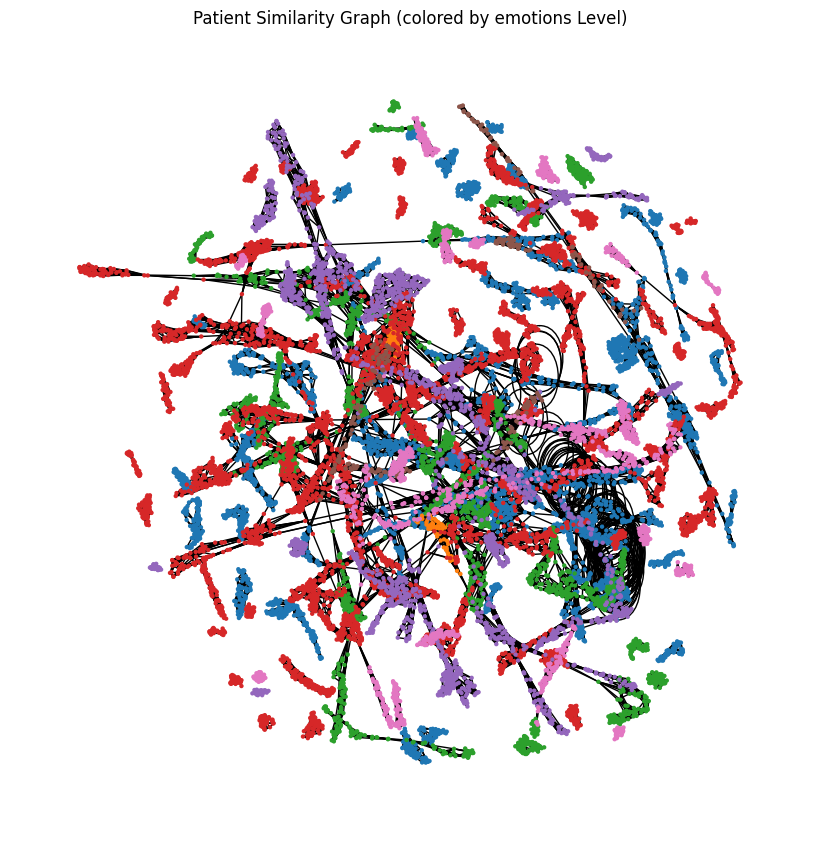

In [11]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# data: your PyG Data object
# Make sure it's on CPU
data_cpu = data.cpu()

# Convert to NetworkX (undirected for nicer layout)
G = to_networkx(data_cpu, to_undirected=True)

palette = [
    'tab:blue', 
    'tab:orange', 
    'tab:green', 
    'tab:red', 
    'tab:purple', 
    'tab:brown', 
    'tab:pink'
]

# Node colors based on emotions Level (0 to 6)
y = data_cpu.y.numpy()
color_map = [palette[label] for label in y]

# Spring layout (force-directed)
pos = nx.spring_layout(G, k=0.1, iterations=50)

plt.figure(figsize=(8, 8))
nx.draw(
    G, pos,
    node_color=color_map,
    node_size=10,
    edge_color='black',
    linewidths=0
)
plt.axis('off')
plt.title("Patient Similarity Graph (colored by emotions Level)")
plt.show()

C:\Users\Sad Bin Siddique\AppData\Local\Temp\ipykernel_3220\703610182.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


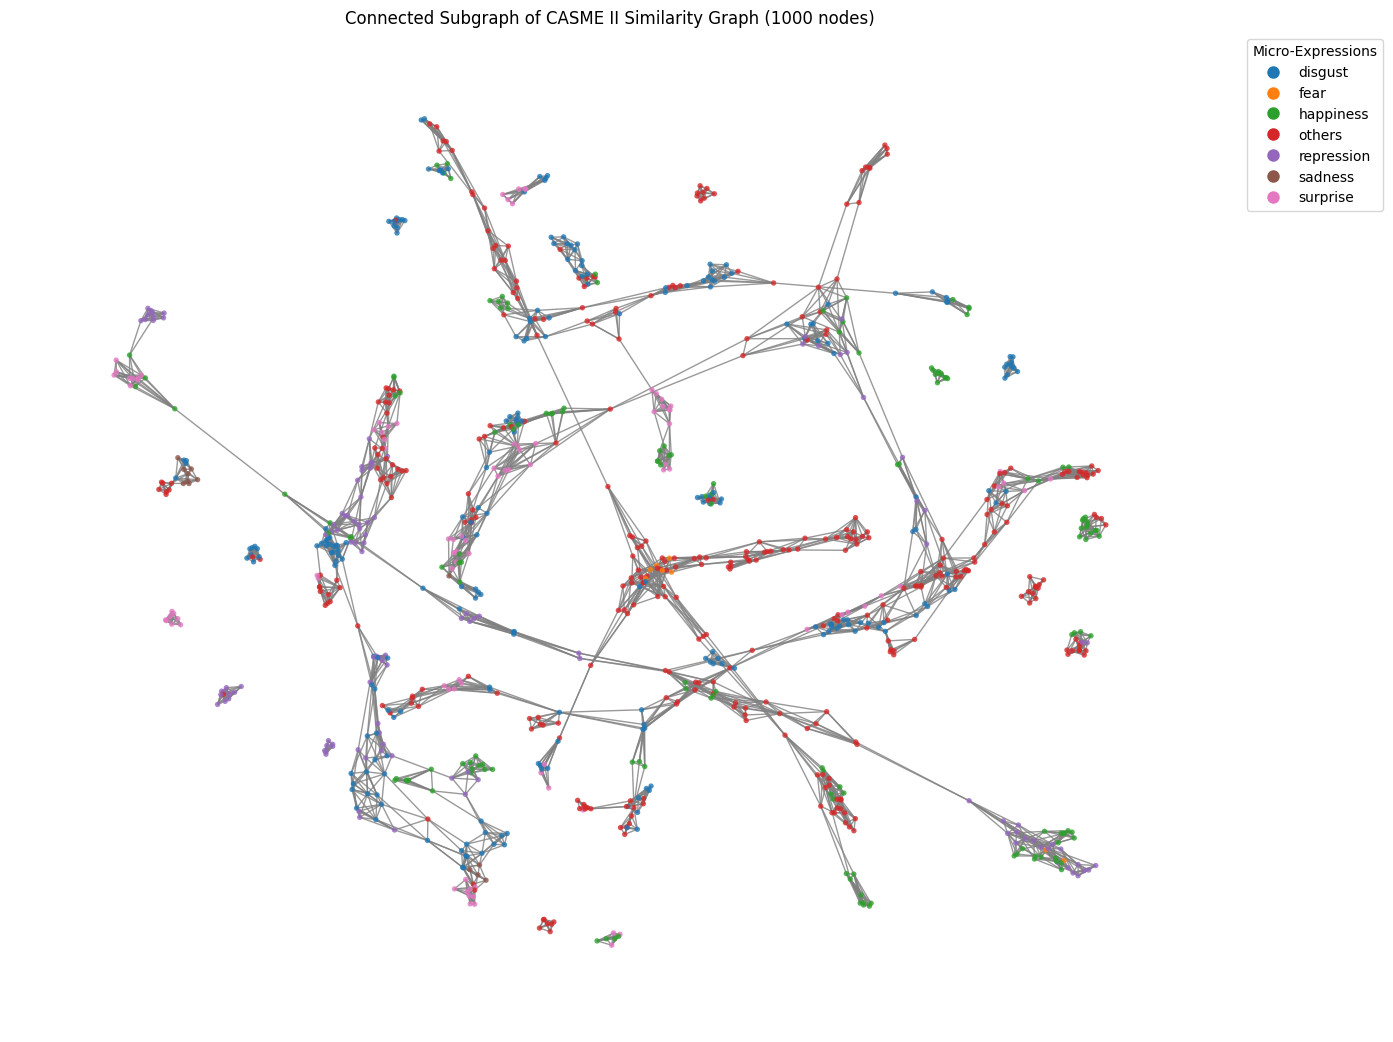

In [26]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from sklearn.neighbors import NearestNeighbors

num_nodes_to_plot = 1000

# 1. Randomly sample the features and labels of 500 nodes
subset_idx = torch.randperm(data_cpu.num_nodes)[:num_nodes_to_plot]
x_sub = data_cpu.x[subset_idx].numpy()
y_sub = data_cpu.y[subset_idx].numpy()

# 2. RECOMPUTE the k-NN edges specifically for this subset so they connect
k = 6  
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(x_sub)
distances, indices = nbrs.kneighbors(x_sub)

edge_index_list = []
for i in range(indices.shape[0]):
    for j in indices[i][1:]:
        edge_index_list.append([i, j])
        edge_index_list.append([j, i])

edge_index_sub = torch.tensor(np.array(edge_index_list).T, dtype=torch.long)

# 3. Create a new Data object with the connected subset
sub_data = Data(x=torch.tensor(x_sub), edge_index=edge_index_sub, y=torch.tensor(y_sub))
G_sub = to_networkx(sub_data, to_undirected=True)

# 4. Plotting setup
casme_classes = ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise']
palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
color_map_sub = [palette[label] for label in y_sub]

# Note: spring_layout is very slow for 2500 nodes. 
# Lowering 'k' to 0.05 helps pull dense clusters apart slightly.
pos_sub = nx.spring_layout(G_sub, k=0.05, iterations=30) 

plt.figure(figsize=(12, 10))
nx.draw(
    G_sub, pos_sub,
    node_color=color_map_sub,
    node_size=15,
    edge_color='gray',
    alpha=0.8,
    linewidths=0
)

# Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=casme_classes[i],
           markerfacecolor=palette[i], markersize=10)
    for i in range(len(casme_classes))
]
plt.legend(handles=legend_elements, title="Micro-Expressions", loc='upper right', bbox_to_anchor=(1.15, 1))

plt.axis('off')
plt.title(f"Connected Subgraph of CASME II Similarity Graph ({num_nodes_to_plot} nodes)")
plt.tight_layout()
plt.show()